In [22]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [23]:
PROJECT_ROOT = Path().cwd().parent 
DATA_PATH = PROJECT_ROOT / 'data' / 'Raw'
application_train = pd.read_csv(DATA_PATH / 'application_train.csv')

**3.1 Target Analysis**

In [24]:
application_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [25]:
application_train['TARGET'].value_counts(normalize= True) * 100 

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

the target variable is highly imbalanced. Approximately 92% of applicants did not default on their loans (TARGET = 0), while only about 8% defaulted (TARGET = 1).

This imbalance should be considered during the modeling phase because a model that always predicts the majority class could still achieve high accuracy while failing to identify high-risk customers.

**3.2 Numerical Features effect**

3.2.1 finance information

In [26]:
finance_information = [
    'AMT_INCOME_TOTAL' , 
    'AMT_CREDIT' , 
    'AMT_ANNUITY' , 
    'AMT_GOODS_PRICE']

application_train[finance_information]

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
0,202500.0,406597.5,24700.5,351000.0
1,270000.0,1293502.5,35698.5,1129500.0
2,67500.0,135000.0,6750.0,135000.0
3,135000.0,312682.5,29686.5,297000.0
4,121500.0,513000.0,21865.5,513000.0
...,...,...,...,...
307506,157500.0,254700.0,27558.0,225000.0
307507,72000.0,269550.0,12001.5,225000.0
307508,153000.0,677664.0,29979.0,585000.0
307509,171000.0,370107.0,20205.0,319500.0


3.2.2 personal information

In [31]:
personal_information = [
    'DAYS_BIRTH' ,
    'DAYS_EMPLOYED' , 
    'CNT_CHILDREN' , 
    'CNT_FAM_MEMBERS'
]

application_train[personal_information]

,DAYS_BIRTH,DAYS_EMPLOYED,CNT_CHILDREN,CNT_FAM_MEMBERS
0,-9461,-637,0,1.0
1,-16765,-1188,0,2.0
2,-19046,-225,0,1.0
3,-19005,-3039,0,2.0
4,-19932,-3038,0,1.0
...,...,...,...,...
307506,-9327,-236,0,1.0
307507,-20775,365243,0,1.0
307508,-14966,-7921,0,1.0
307509,-11961,-4786,0,2.0


3.2.3 Home information

In [35]:
home_information = [
    'APARTMENTS_AVG' , 
    'BASEMENTAREA_AVG' , 
    'YEARS_BUILD_AVG'
]
application_train[home_information]

,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BUILD_AVG
0,0.0247,0.0369,0.6192
1,0.0959,0.0529,0.7960
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
307506,0.2021,0.0887,0.8300
307507,0.0247,0.0435,0.6260
307508,0.1031,0.0862,0.7484
307509,0.0124,NaN,NaN


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore 

In [84]:
def analyze_feature_group(application_train , features) :
    summary = []

    # summary table 
    for col in features :
        series = application_train[col].dropna() 
        z_scores = np.abs(zscore(series))

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1 

        lower = q1 - 1.5 * iqr 
        upper = q3 + 1.5 * iqr 

        iqr_outliers = ((series < lower) | (series > upper)).sum()
        

        summary.append({
            'Feature' : col , 
            'Missing' : application_train[col].isna().sum() , 
            'Missing %' : round(application_train[col].isna().mean()*100 , 2) ,
            'Mean' : round(series.mean() , 2) , 
            'Median' : round(series.median() , 2 ) , 
            'Std' : round(series.std() , 2) , 
            'Skewness' : round(series.skew() , 2) , 
            'Kurtosis' : round(series.kurt() , 2) , 
            'Max Z-score' : round(z_scores.max() , 2) , 
            'IQR Outliers' : iqr_outliers
        })

    summary_df = pd.DataFrame(summary)
    display(summary_df)


    # histograms 

    n = len(features)
    rows = int(np.ceil(n / 2))
    fig , axes = plt.subplots(rows , 2 , figsize = (12 , rows * 4))
    axes = axes.flatten()

    mean = series.mean()
    median = series.median()

    for i , col in enumerate(features) : 
        axes[i].hist(application_train[col].dropna() , bins = 30)
        axes[i].set_title(col)
        

    for j in range(i + 1 , len(axes)) : 
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()



    # boxplots 

    fig , axes = plt.subplots(rows , 2 , figsize = (12 , rows * 4))

    axes = axes.flatten()

    for i , col in enumerate(features) :
        application_train.boxplot(column = col , 
                                  by = 'TARGET' , 
                                  ax = axes[i])
        axes[i].set_title(col)

    for j in range(i + 1 , len(axes)) : 
        fig.delaxes(axes[j])
    
    plt.suptitle('')
    plt.tight_layout()
    plt.show()


    return summary_df


,Feature,Missing,Missing %,Mean,Median,Std,Skewness,Kurtosis,Max Z-score,IQR Outliers
0,DAYS_BIRTH,0,0.0,-16037.00,-15750.0,4363.99,-0.12,-1.05,2.11,0
1,DAYS_EMPLOYED,0,0.0,63815.05,-1213.0,141275.77,1.66,0.77,2.13,72217
2,CNT_CHILDREN,0,0.0,0.42,0.0,0.72,1.97,7.90,25.73,4272
3,CNT_FAM_MEMBERS,2,0.0,2.15,2.0,0.91,0.99,2.80,19.60,4007


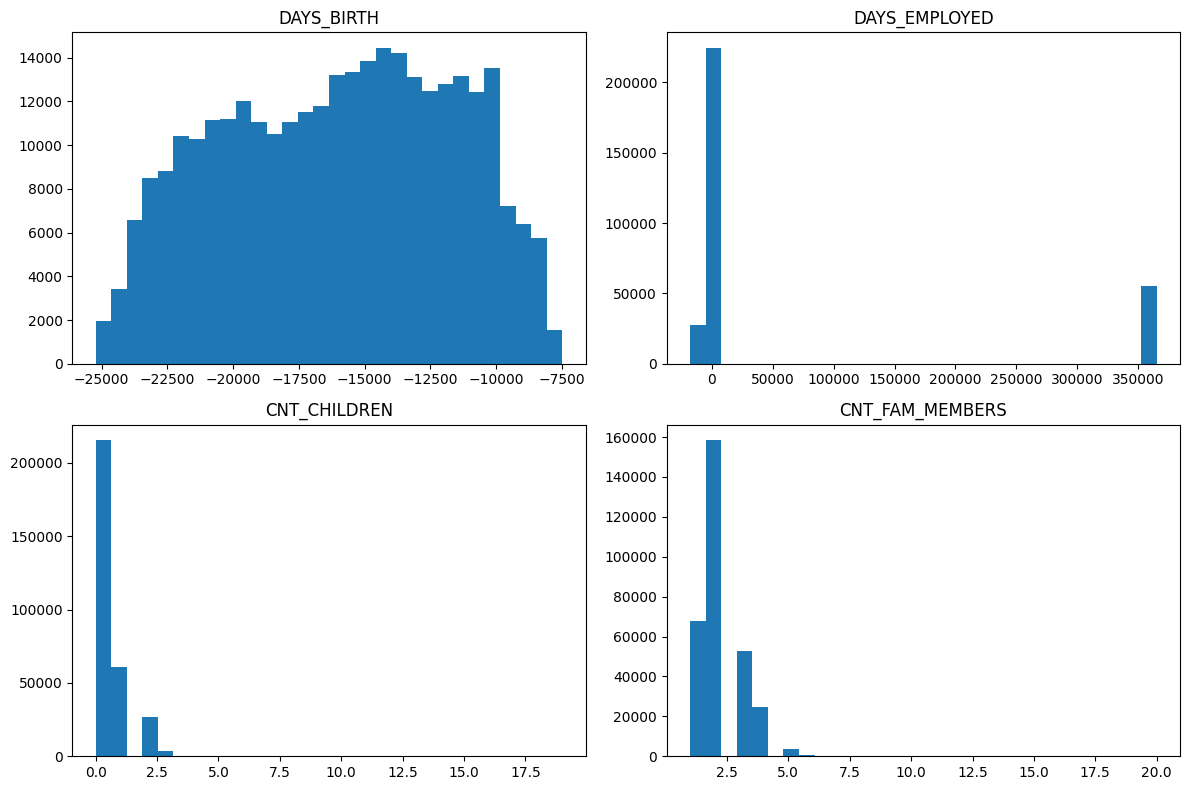

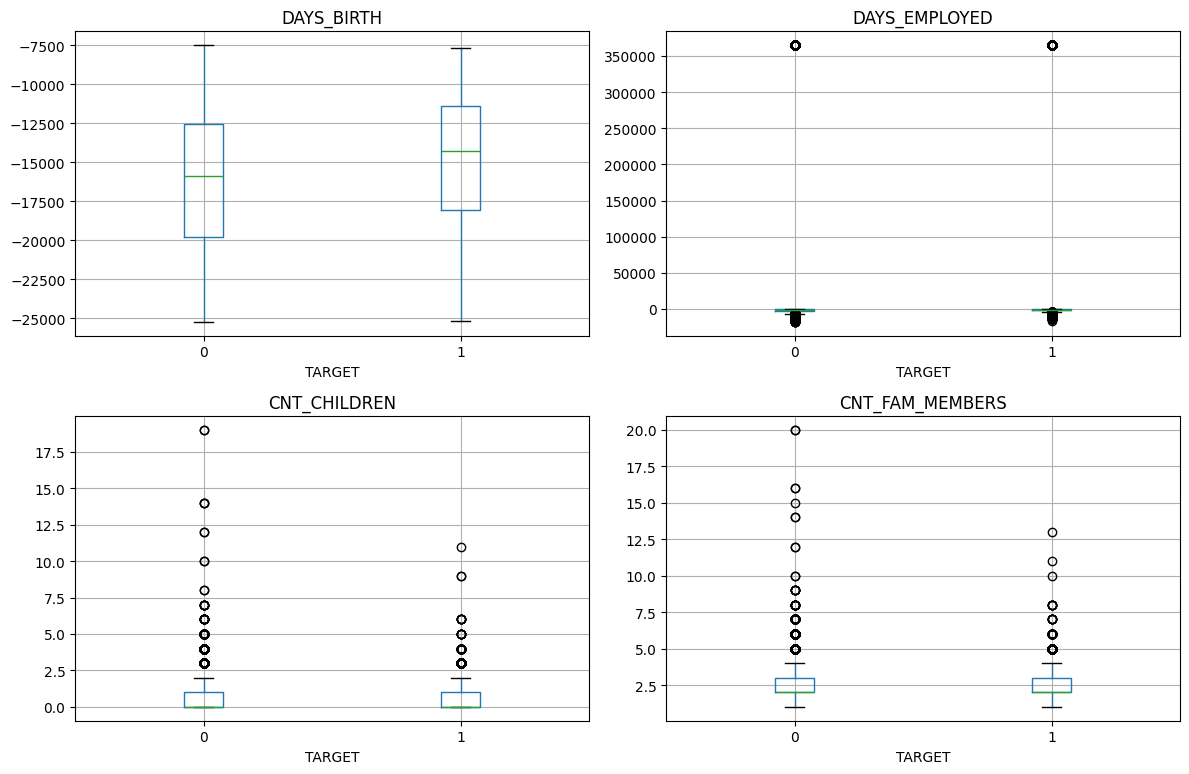

In [85]:
personal_summary_df = analyze_feature_group(
    application_train , 
    personal_information 
)

,Feature,Missing,Missing %,Mean,Median,Std,Skewness,Kurtosis,Max Z-score,IQR Outliers
0,APARTMENTS_AVG,156061,50.75,0.12,0.09,0.11,2.64,11.39,8.15,10655
1,BASEMENTAREA_AVG,179943,58.52,0.09,0.08,0.08,3.57,25.93,11.06,7190
2,YEARS_BUILD_AVG,204488,66.50,0.75,0.76,0.11,-0.96,4.40,6.64,2154


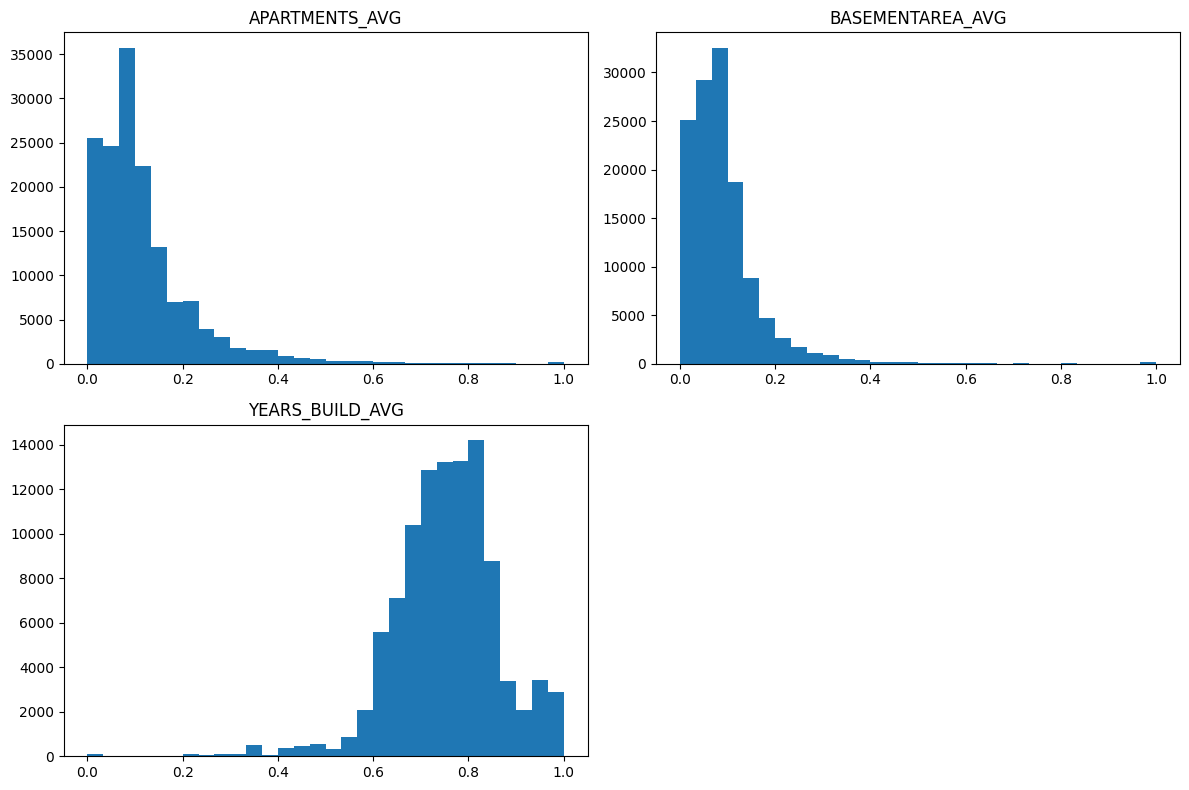

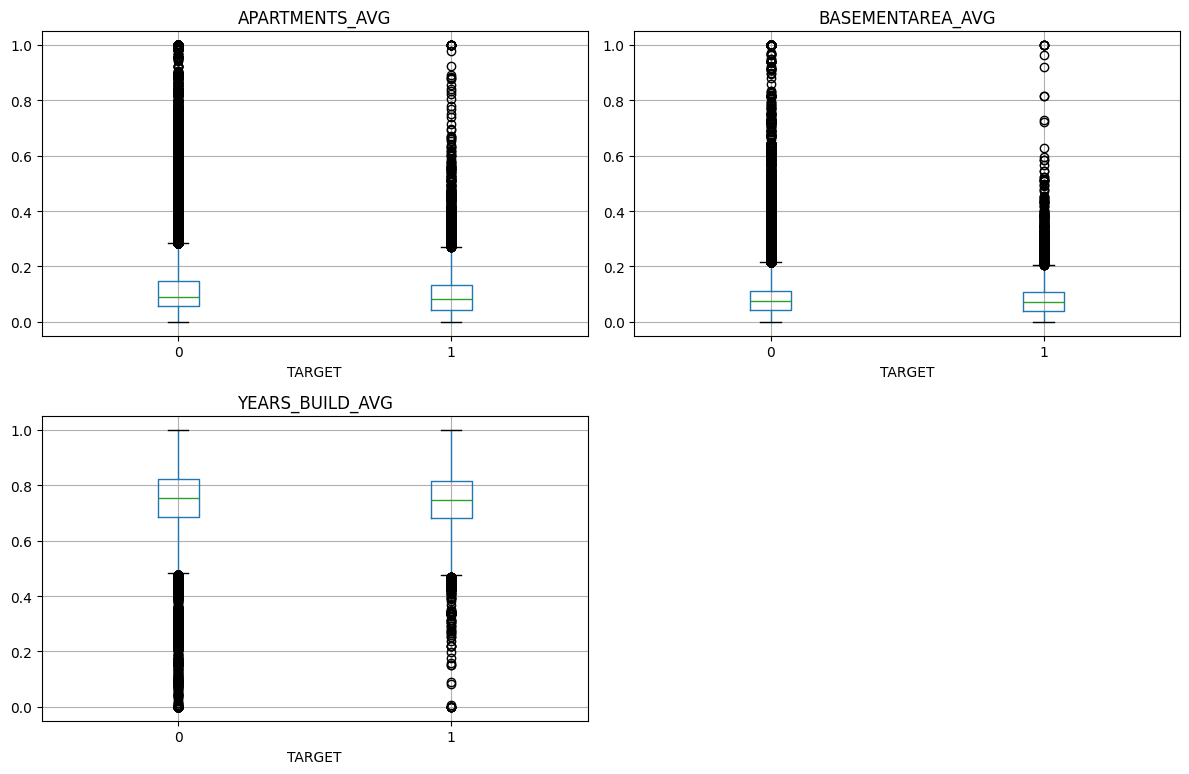

In [78]:
home_summary_df = analyze_feature_group (
    application_train , 
    home_information 
)

,Feature,Missing,Missing %,Mean,Median,Std,Skewness,Kurtosis,Max Z-score,IQR Outliers
0,AMT_INCOME_TOTAL,0,0.00,168797.92,147150.0,237123.15,391.56,191786.55,492.70,14035
1,AMT_CREDIT,0,0.00,599026.00,513531.0,402490.78,1.23,1.93,8.57,6562
2,AMT_ANNUITY,12,0.00,27108.57,24903.0,14493.74,1.58,7.71,15.93,7504
3,AMT_GOODS_PRICE,278,0.09,538396.21,450000.0,369446.46,1.35,2.43,9.51,14728


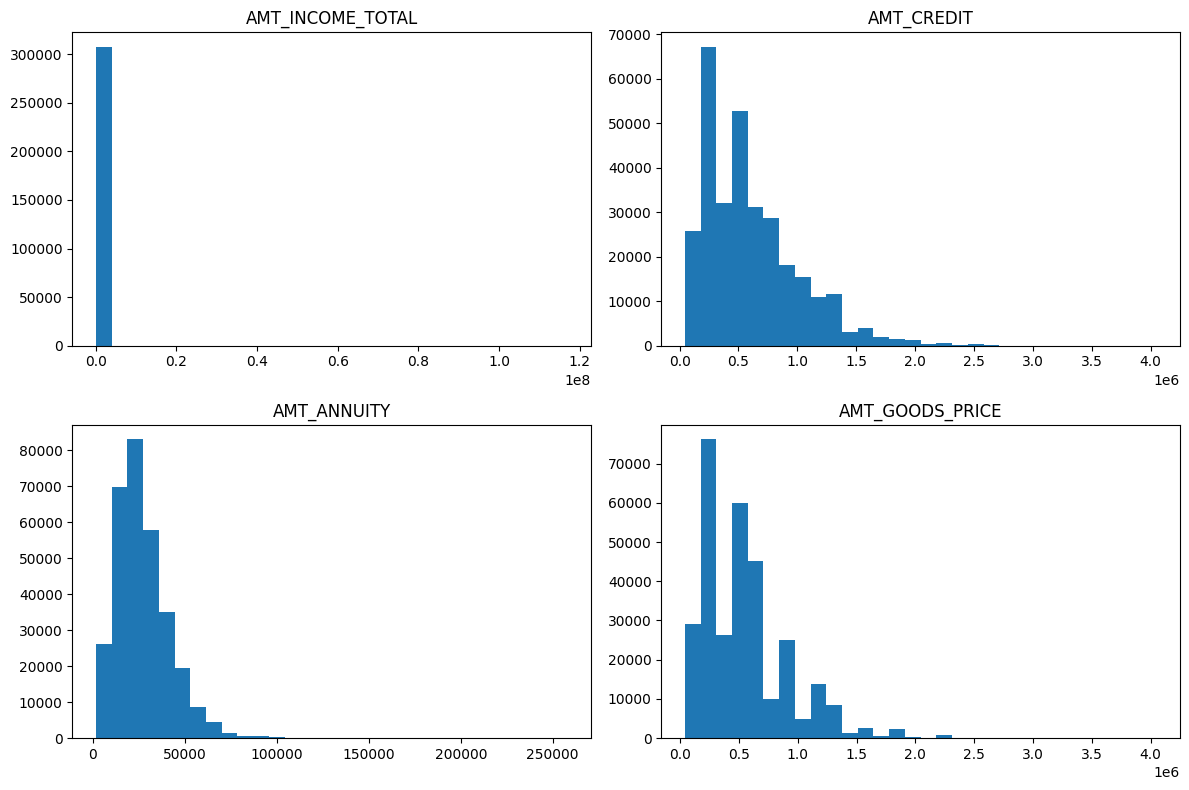

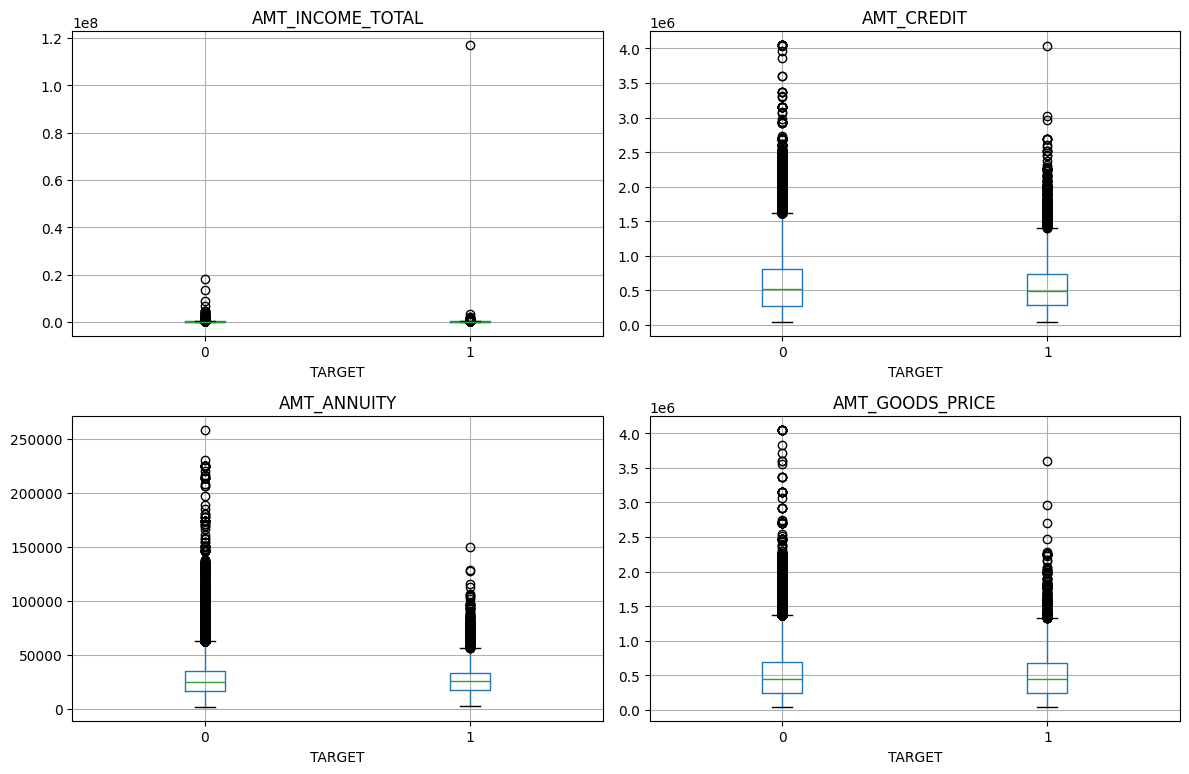

In [79]:
finance_summary_df = analyze_feature_group(
    application_train , 
    finance_information
)

In [82]:
from IPython.display import display 

display(
    home_summary_df.style
    .background_gradient(
        subset=['Missing %'] , 
        cmap = 'Reds'
    )
    .background_gradient(
        subset=['Skewness'] , 
        cmap = 'Oranges'
    )
    .background_gradient(
        subset=['IQR Outliers'] , 
        cmap = 'Purples'
    )
    .format({
        "Missing %":"{:.2f}",
        "Mean":"{:.2f}",
        "Median":"{:.2f}",
        "Std":"{:.2f}",
        "Skewness":"{:.2f}",
        "Kurtosis":"{:.2f}",
        "Max Z-score":"{:.2f}"
    })
)



display(
    finance_summary_df.style
    .background_gradient(
        subset=['Missing %'] , 
        cmap = 'Reds'
    )
    .background_gradient(
        subset=['Skewness'] , 
        cmap = 'Oranges'
    )
    .background_gradient(
        subset=['IQR Outliers'] , 
        cmap = 'Purples'
    )
    .format({
        "Missing %":"{:.2f}",
        "Mean":"{:.2f}",
        "Median":"{:.2f}",
        "Std":"{:.2f}",
        "Skewness":"{:.2f}",
        "Kurtosis":"{:.2f}",
        "Max Z-score":"{:.2f}"
    })
)



from IPython.display import display 

display(
    personal_summary_df.style
    .background_gradient(
        subset=['Missing %'] , 
        cmap = 'Reds'
    )
    .background_gradient(
        subset=['Skewness'] , 
        cmap = 'Oranges'
    )
    .background_gradient(
        subset=['IQR Outliers'] , 
        cmap = 'Purples'
    )
    .format({
        "Missing %":"{:.2f}",
        "Mean":"{:.2f}",
        "Median":"{:.2f}",
        "Std":"{:.2f}",
        "Skewness":"{:.2f}",
        "Kurtosis":"{:.2f}",
        "Max Z-score":"{:.2f}"
    })
)

,Feature,Missing,Missing %,Mean,Median,Std,Skewness,Kurtosis,Max Z-score,IQR Outliers
0,APARTMENTS_AVG,156061,50.75,0.12,0.09,0.11,2.64,11.39,8.15,10655
1,BASEMENTAREA_AVG,179943,58.52,0.09,0.08,0.08,3.57,25.93,11.06,7190
2,YEARS_BUILD_AVG,204488,66.50,0.75,0.76,0.11,-0.96,4.40,6.64,2154


,Feature,Missing,Missing %,Mean,Median,Std,Skewness,Kurtosis,Max Z-score,IQR Outliers
0,AMT_INCOME_TOTAL,0,0.00,168797.92,147150.00,237123.15,391.56,191786.55,492.70,14035
1,AMT_CREDIT,0,0.00,599026.00,513531.00,402490.78,1.23,1.93,8.57,6562
2,AMT_ANNUITY,12,0.00,27108.57,24903.00,14493.74,1.58,7.71,15.93,7504
3,AMT_GOODS_PRICE,278,0.09,538396.21,450000.00,369446.46,1.35,2.43,9.51,14728


,Feature,Missing,Missing %,Mean,Median,Std,Skewness,Kurtosis,Max Z-score,IQR Outliers
0,DAYS_BIRTH,0,0.00,-16037.00,-15750.00,4363.99,-0.12,-1.05,2.11,0
1,DAYS_EMPLOYED,0,0.00,63815.05,-1213.00,141275.77,1.66,0.77,2.13,72217
2,CNT_CHILDREN,0,0.00,0.42,0.00,0.72,1.97,7.90,25.73,4272
3,CNT_FAM_MEMBERS,2,0.00,2.15,2.00,0.91,0.99,2.80,19.60,4007
